In [ ]:
import os
import sys
import numpy as np
import pandas as pd
from pathlib import Path
import umap
import hdbscan
import matplotlib.pyplot as plt
import pickle
from tqdm.notebook import tqdm

In [ ]:
cur_dir = os.getcwd().split('\\')

if cur_dir[-1] == 'notebooks':
    os.chdir("..")

from utils.data_load_utilities.data_loader import load_model_results
from utils.get_global_const import get_global_const
from utils.get_metrics import get_metrics
from utils.get_ranks import get_ranks_s, get_ranks
from methods.ADoE_method import *
from methods.k_nearest_methods import *
from methods.kmeans_methods import *
from methods.opt_methods import *
from methods.sparce_methods import *
from methods.entrophy_metods import *

from testing_pipeline.testing_pipeline_stats import *

from sklearn.linear_model import LassoCV
from sklearn.feature_selection import mutual_info_regression

from datetime import datetime
import re

import warnings
warnings.simplefilter('ignore')

In [ ]:
scores, datasets, models = get_global_const()
scores

In [ ]:
tsfresh_features = pd.read_csv(Path('data/datasets_features/tsfresh_important_features.csv'), index_col=0)
# tsfresh_features

In [ ]:
# chosen_datasets = tsfresh_features.Name.values
chosen_datasets = sorted(datasets)
chosen_datasets[:5]

In [ ]:
features = pd.read_csv(Path('data/datasets_features/features.csv'), index_col=0)
features = features.set_index('Name')
features = features.loc[chosen_datasets, :]
features = features.reset_index()
features

In [ ]:
sf = features.drop(columns=['Name']).copy()

In [ ]:
scores_aggr = {
    model: model_score[model_score["folds:"].isin(chosen_datasets)].reset_index(drop=True) for model, model_score in scores.items()
}

scores_aggr = {
    model: model_score.set_index("folds:").loc[chosen_datasets, :].reset_index() for model, model_score in scores_aggr.items()
}

scores_aggr = {
    model: model_score[model_score.columns[1:]].mean(axis=1) for model, model_score in scores_aggr.items()
}

scores_aggr = pd.DataFrame(scores_aggr)

scores_aggr

In [ ]:
prep_features = features.copy()
prep_features = prep_features.drop(columns=['Name'])
prep_features['size'] = np.log(prep_features['size'])
prep_features

In [ ]:
prep_tsfresh_features = tsfresh_features.copy()
prep_tsfresh_features = prep_tsfresh_features.drop(columns=['Name'])
prep_tsfresh_features

In [ ]:
nn_clusters = [2, 3, 4, 5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 109]

In [ ]:
chosen_datasets = np.array(chosen_datasets)

In [ ]:
ranks = get_ranks_s(chosen_datasets, scores, datasets, return_ranks=True)
ranks_all = get_ranks_s(chosen_datasets, scores, datasets, return_ranks=False)

In [ ]:
# 1/0

In [ ]:
# ranks

In [ ]:
metrics = ['MAE', 'MSE', 'Kendall', 'Spearman', 'Pearson', 'Mutual information', 'Adjusted mutual information', 'Normalized mutual information', 'Cramers V', 'Point-Biserial Correlation', 'Phi Coefficient', 'Bloomquist Beta', 'Rank Correlation Ratio', 'Xi Correlation', 'Distance Correlation', 'Me', 'repr']

In [ ]:
def random_ind_metr(data: pd.DataFrame, indexes_list, sample_size: int, test_ind, datasets, iter=100, inner_iter=10):
    
    sum_metrics = None
    
    for i in range(iter):
        
        for _ in range(inner_iter):
        
            data_train = data.loc[indexes_list[i]]
            
            indxs = np.random.choice(data_train.index, sample_size, replace=False)
            
            repr_simple = chosen_datasets[[indxs]].squeeze()
        
            ranks_simple = get_ranks(repr_simple, ranks)
            metr = get_metrics(get_ranks(datasets[test_ind].squeeze(), ranks), ranks_simple)
            
            if sum_metrics is None:
                sum_metrics = metr.copy()
            else:
                for key in sum_metrics:
                    sum_metrics[key] += metr[key]

    averaged_metrics = {key: value / (iter * inner_iter) for key, value in sum_metrics.items()}

    return averaged_metrics
    

In [ ]:
targets = np.array(scores_aggr.mean(axis=1))

In [ ]:
tsfresh_features_full = pd.read_csv(Path('data/datasets_features/tsfresh_full_features.csv'), index_col=0)
prep_tsfresh_features_full = tsfresh_features_full.copy().set_index("Name").loc[chosen_datasets, :]
prep_tsfresh_features_full = prep_tsfresh_features_full.reset_index().drop(columns=['Name'])
prep_tsfresh_features_full = prep_tsfresh_features_full.dropna(axis=1)
prep_tsfresh_features_full = prep_tsfresh_features_full.drop(columns=prep_tsfresh_features_full.columns[(prep_tsfresh_features_full.abs() > 1e9).any()])
constant_features = [col for col in prep_tsfresh_features_full.columns if prep_tsfresh_features_full[col].nunique() <= 1]
prep_tsfresh_features_full = prep_tsfresh_features_full.drop(columns=constant_features)
prep_tsfresh_features_full

In [ ]:
meta_tsfresh = pd.read_csv(Path('data/datasets_features/apriori_meta_tsfresh_probe.csv'), index_col=0).reset_index(drop=True)
meta_tsfresh.head()

In [ ]:
meta_catch22 = pd.read_csv(Path('data/datasets_features/apriori_meta_catch22_probe.csv'), index_col=0).reset_index(drop=True)
meta_catch22.head()

In [ ]:
meta_summary = pd.read_csv(Path('data/datasets_features/apriori_meta_summary_probe.csv'), index_col=0).reset_index(drop=True)
meta_summary.head()

In [ ]:
ranks_aggr = pd.DataFrame(columns=chosen_datasets)

for d in chosen_datasets:
    ranks_aggr[d] = ranks[d].drop(columns=['model']).mean(axis=1)

ranks_aggr.transpose()

In [ ]:
ranks_aggr_rounded = ranks_aggr.rank(axis=0)
ranks_aggr_rounded[:5]

In [ ]:
tsf = pd.read_csv("data/datasets_features/dataset_level/tsfresh_dataset_mean.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])
c22 = pd.read_csv("data/datasets_features/dataset_level/catch22_dataset_mean.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])
mr  = pd.read_csv("data/datasets_features/dataset_level/minirocket_dataset_mean.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])
sm  = pd.read_csv("data/datasets_features/dataset_level/summary_dataset_mean.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])

In [ ]:
tsf.head()

In [ ]:
lm = pd.read_csv("data/datasets_features/landmarking_raw.csv").sort_values("dataset").set_index("dataset").loc[chosen_datasets, :].reset_index().drop(columns=['dataset'])

In [ ]:
tsf = tsf.dropna(axis=1)
tsf = tsf.drop(columns=tsf.columns[(tsf.abs() > 1e9).any()])
constant_features = [col for col in tsf.columns if tsf[col].nunique() <= 1]
tsf = tsf.drop(columns=constant_features)
tsf

In [ ]:
tsf.isna().values.any()

In [ ]:
def a_optimality_ind(data,
                     sample_size: int,
                     model_list=None,
                     scale_data: bool = True,
                     iter: int = 100,
                     alpha: float = 1e-4,
                     random_state: int = 42,
                     pca_099 = False,
                     **kwargs):

    X = np.asarray(data)
    
    if pca_099:
        X = np.array(StandardScaler().fit_transform(X))
        X = PCA(0.99).fit_transform(X) 

    if scale_data:
        X = StandardScaler().fit_transform(X)

    df = pd.DataFrame(X)
    
    return a_d_optimality_ind(df,
                              sample_size=sample_size,
                              optimality='a',
                              iter=iter,
                              alpha=alpha,
                              random_state=random_state,
                              return_ind=True)


def d_optimality_ind(data,
                     sample_size: int,
                     model_list=None,
                     scale_data: bool = True,
                     iter: int = 100,
                     alpha: float = 1e-4,
                     random_state: int = 42,
                     pca_099 = False,
                     **kwargs):

    X = np.asarray(data)
    
    if pca_099:
        X = np.array(StandardScaler().fit_transform(X))
        X = PCA(0.99).fit_transform(X) 

    if scale_data:
        X = StandardScaler().fit_transform(X)

    df = pd.DataFrame(X)
    return a_d_optimality_ind(df,
                              sample_size=sample_size,
                              optimality='d',
                              iter=iter,
                              alpha=alpha,
                              random_state=random_state,
                              return_ind=True)

In [70]:
metods_data_list = [
    [rand_ind_method, c22.values,
     range(2, 21),
     False, False,
     {},
     False, False,
     'Random'],
    
    [get_more_different_datasets,
    sf.values,
    range(2, 21),
    False,
    False,
    {'scale_data': True},
    False,
    False,
    'Cosine FF'],
    
    [get_more_different_datasets,
    sf.values,
    range(2, 21),
    False,
    False,
    {'scale_data': True},
    False,
    False,
    'K-Means'],
    
    [k_means_ind,
    sf.values,
    range(2, 21),
    False,
    False,
    {'scale_data': True},
    False,
    False,
    'Euclid FF'],
    
    # [a_optimality_ind, sf.values,
    #  range(2, 21),
    #  False, False,
    #  {'scale_data': True, 'iter': 2, 'alpha': 1e-4, 'random_state': 42},
    #  False, False,
    #  'A-opt ORACLE'],

    # [d_optimality_ind, sf.values,
    #  range(2, 21),
    #  False, False,
    #  {'scale_data': True, 'iter': 2, 'alpha': 1e-4, 'random_state': 42},
    #  False, False,
    #  'D-opt ORACLE'],
]

Loading Random results...
Loading Cosine FF results...
Loading K-Means results...
Loading Euclid FF results...
Random                    | Kendall  | AUC(mean)=13.12, AUC(std)=0.64, AUC(q2.5)=9.7206, AUC(q97.5)=15.8200, delta=6.0994
Cosine FF                 | Kendall  | AUC(mean)=13.40, AUC(std)=1.07, AUC(q2.5)=10.2467, AUC(q97.5)=15.8763, delta=5.6296
K-Means                   | Kendall  | AUC(mean)=13.15, AUC(std)=0.73, AUC(q2.5)=9.7553, AUC(q97.5)=15.8330, delta=6.0777
Euclid FF                 | Kendall  | AUC(mean)=13.13, AUC(std)=1.18, AUC(q2.5)=9.6826, AUC(q97.5)=15.7872, delta=6.1046
Random                    | MAE      | AUC(mean)=39.40, AUC(std)=3.18, AUC(q2.5)=19.3676, AUC(q97.5)=64.4833, delta=45.1156
Cosine FF                 | MAE      | AUC(mean)=36.94, AUC(std)=7.32, AUC(q2.5)=18.5511, AUC(q97.5)=60.3336, delta=41.7825
K-Means                   | MAE      | AUC(mean)=39.76, AUC(std)=4.32, AUC(q2.5)=19.3018, AUC(q97.5)=66.8683, delta=47.5665
Euclid FF                 | 

<Figure size 800x600 with 0 Axes>

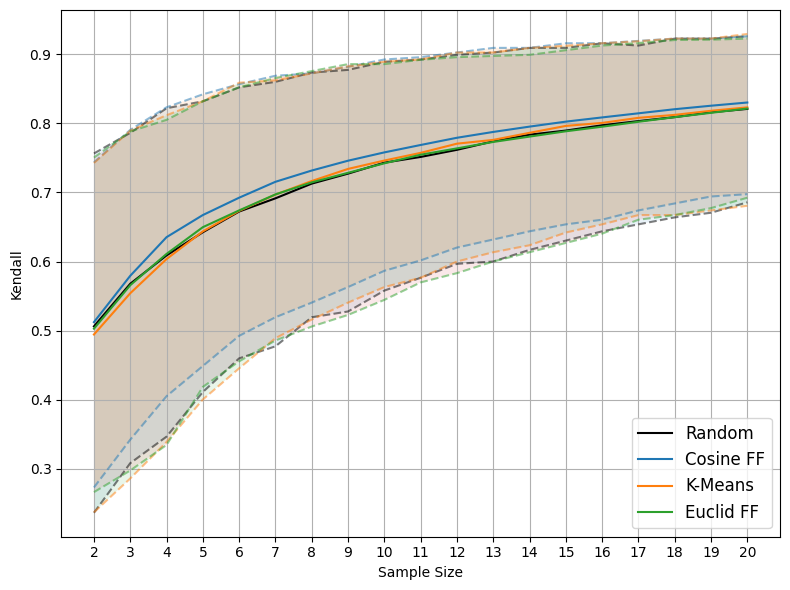

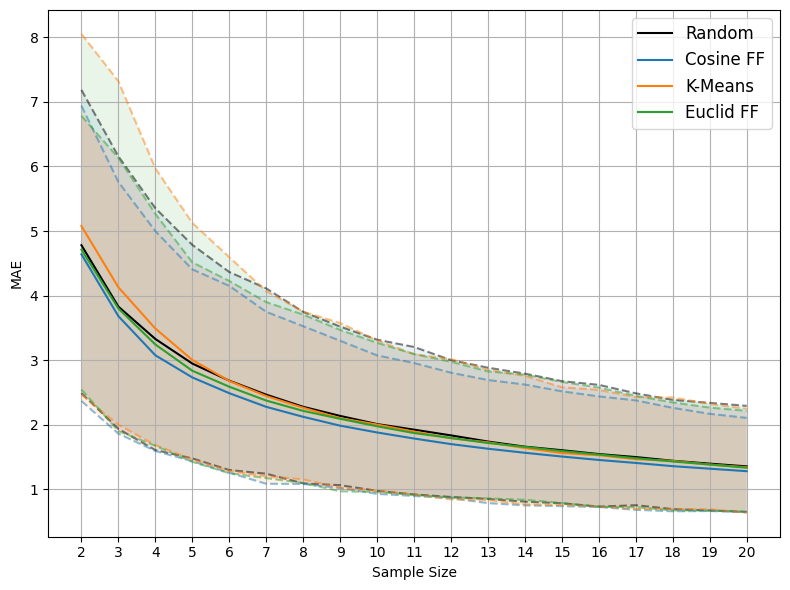

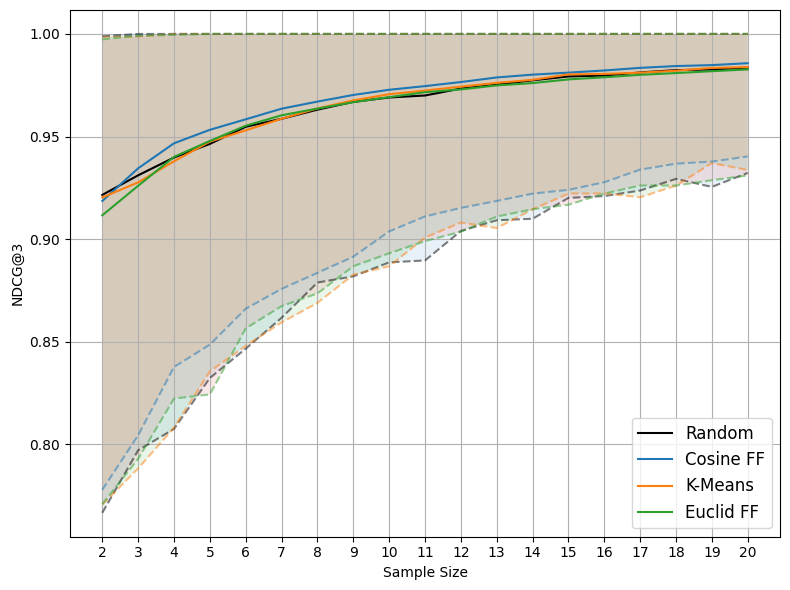

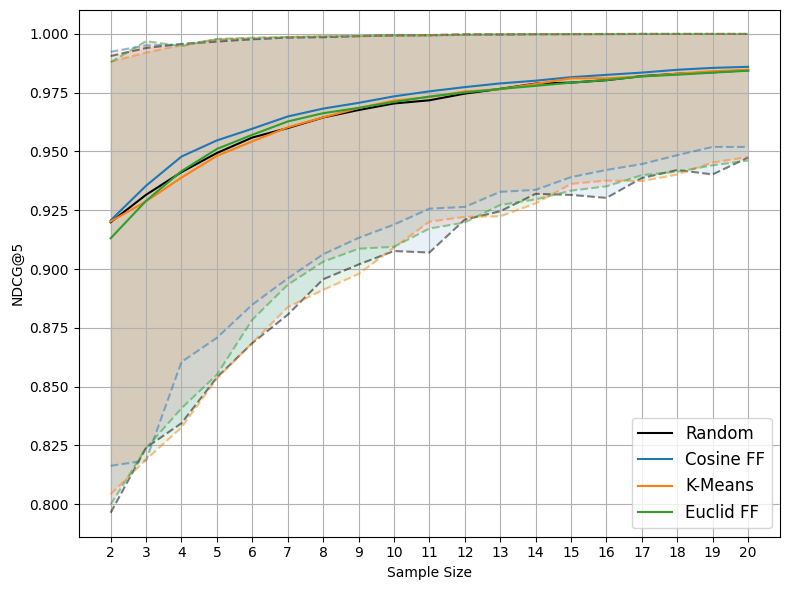

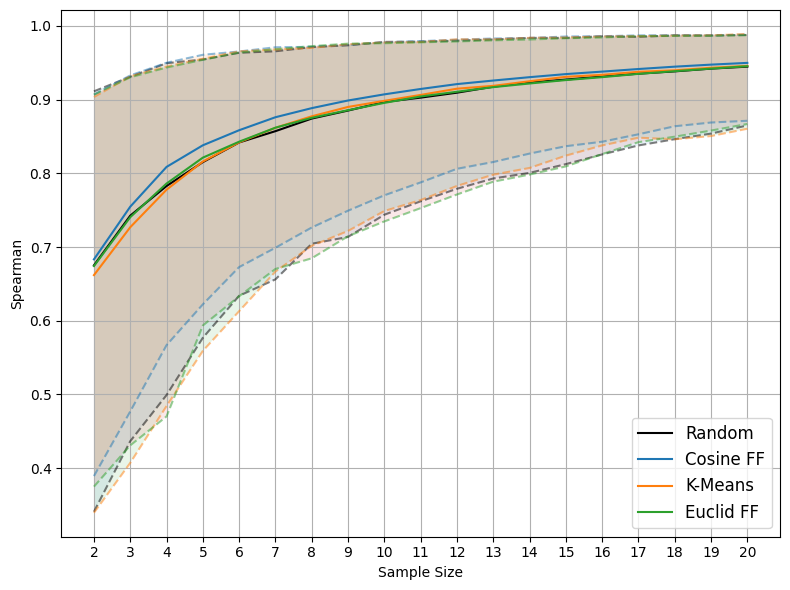

In [71]:
testing_pipeline(chosen_datasets, metods_data_list, ranks, scores, chosen_datasets, ratio=0.8, models_prefix='',
                 load_res=True, save_results=True, save_checpoints=True, test_iter=200,
                 save_check_path=os.path.join('checkpoints', 'full_testing_ch', '1_LAST_BROKEN'))

In [ ]:
import re
from pathlib import Path
from typing import Iterable, Dict, Tuple, List, Optional

LINE_RE = re.compile(r'^(?P<method>.+?)\s*\|\s*(?P<metric>[^|]+?)\s*\|\s*(?P<rest>.+)$')
MEAN_RE = re.compile(r'AUC\(mean\)\s*=\s*([0-9]*\.?[0-9]+)')
STD_RE  = re.compile(r'AUC\(std\)\s*=\s*([0-9]*\.?[0-9]+)')

def parse_auc_table(
    filepath: str,
    wanted_metrics: Iterable[str] = ("MAE", "Spearman", "NDCG@5", "Kendall"),
    decimals: int = 2,
) -> str:
    """
    LaTeX-строки:
        Method & mean ± std & ... \\\\
    Подсветка ТОЛЬКО mean:
      - MAE: min mean = \\textbf{}, второй min = \\underline{}
      - остальные: max mean = \\textbf{}, второй max = \\underline{}
    """
    wanted_metrics = list(wanted_metrics)

    text = Path(filepath).read_text(encoding="utf-8", errors="ignore")
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]

    data: Dict[str, Dict[str, Tuple[float, float]]] = {}
    method_order: List[str] = []

    for ln in lines:
        m = LINE_RE.match(ln)
        if not m:
            continue

        method = m.group("method").strip()
        metric = m.group("metric").strip()
        rest = m.group("rest")

        mean_m = MEAN_RE.search(rest)
        std_m = STD_RE.search(rest)
        if not (mean_m and std_m):
            continue

        mean = float(mean_m.group(1))
        std = float(std_m.group(1))

        if method not in data:
            data[method] = {}
            method_order.append(method)

        data[method][metric] = (mean, std)

    # highlight[metric] = {"best": set(methods), "second": set(methods)}
    highlight: Dict[str, Dict[str, set]] = {m: {"best": set(), "second": set()} for m in wanted_metrics}

    for metric in wanted_metrics:
        vals = []
        for method in method_order:
            ms = data.get(method, {}).get(metric)
            if ms is None:
                continue
            mean, _ = ms
            vals.append((method, mean))

        if not vals:
            continue

        reverse = (metric != "MAE")  # True => убывание (больше лучше)
        vals_sorted = sorted(vals, key=lambda x: x[1], reverse=reverse)

        best_method, best_val = vals_sorted[0]
        highlight[metric]["best"].add(best_method)

        # второй = следующий отличный по значению mean (на случай равенств)
        second_val = None
        for method, v in vals_sorted[1:]:
            if v != best_val:
                second_val = v
                break

        if second_val is not None:
            for method, v in vals_sorted[1:]:
                if v == second_val:
                    highlight[metric]["second"].add(method)

    def fmt_cell(method: str, metric: str) -> str:
        ms: Optional[Tuple[float, float]] = data.get(method, {}).get(metric)
        if ms is None:
            return r"-- $\pm$ --"

        mean, std = ms
        mean_str = f"{mean:.{decimals}f}"
        std_str  = f"{std:.{decimals}f}"

        if method in highlight[metric]["best"]:
            mean_str = rf"\textbf{{{mean_str}}}"
        elif method in highlight[metric]["second"]:
            mean_str = rf"\underline{{{mean_str}}}"

        return f"{mean_str} $\\pm$ {std_str}"

    out_lines = []
    for method in method_order:
        row = [method] + [fmt_cell(method, metric) for metric in wanted_metrics]
        out_lines.append("    " + " & ".join(row) + r" \\")
    return "\n".join(out_lines)

# пример:
# print(parse_auc_table("/mnt/data/res (2).TXT"))


In [69]:
latex_rows = parse_auc_table("C:\\Users\\Ростислав\\Downloads\\res (2).txt")
print(latex_rows)

    Random & 39.40 $\pm$ 3.18 & 15.83 $\pm$ 0.51 & 17.40 $\pm$ 0.16 & 13.12 $\pm$ 0.64 \\
    Cosine FF & \textbf{36.94} $\pm$ 7.32 & \textbf{16.04} $\pm$ 0.80 & \textbf{17.46} $\pm$ 0.28 & \textbf{13.40} $\pm$ 1.07 \\
    K-Means & 39.76 $\pm$ 4.32 & 15.84 $\pm$ 0.59 & 17.40 $\pm$ 0.21 & \underline{13.15} $\pm$ 0.73 \\
    Euclid FF & \underline{38.63} $\pm$ 7.78 & \underline{15.85} $\pm$ 0.92 & \underline{17.41} $\pm$ 0.32 & 13.13 $\pm$ 1.18 \\
